# Stationary $\theta$ squeezing retrieval

In [1]:
import matplotlib.pyplot as plt
from lecroyparser import ScopeData
import numpy as np

In [ ]:
vacuum_data = ScopeData(path='data/C1sn00010.trc',parseAll=False)
vacuum_data_x = vacuum_data.x[:-2]
vacuum_data_y = vacuum_data.y[:-2]

plt.figure()
plt.plot(vacuum_data_x,vacuum_data_y)

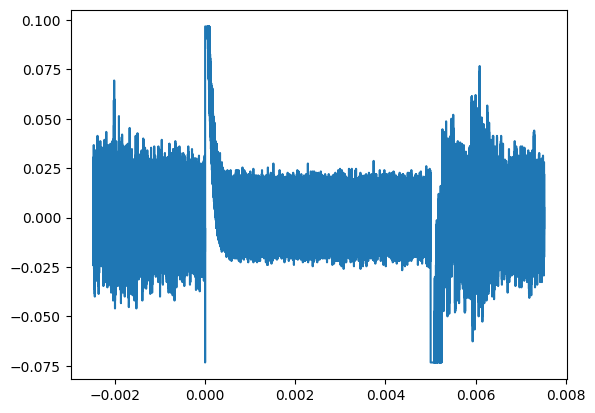

In [ ]:
squeezed_light_data = ScopeData(path='data/C1smsv00000.trc',parseAll=False)
squeezed_light_x = squeezed_light_data.x[:-2]
squeezed_light_y = squeezed_light_data.y[:-2]

plt.figure()
plt.plot(squeezed_light_x, squeezed_light_y)

Since from theory we know that vacuum noise variance is supposed to be 1/2 we calculate normalization factor, which could be applied to actual data and normalize the variance 

In [ ]:
vacuum_variance = np.var(vacuum_data_y)
normalization_factor = vacuum_variance / 0.5
print(f"var = {vacuum_variance:.4e}, normalization factor = {normalization_factor:.4e}")

var = 3.5309e-05, normalization factor = 7.0619e-05


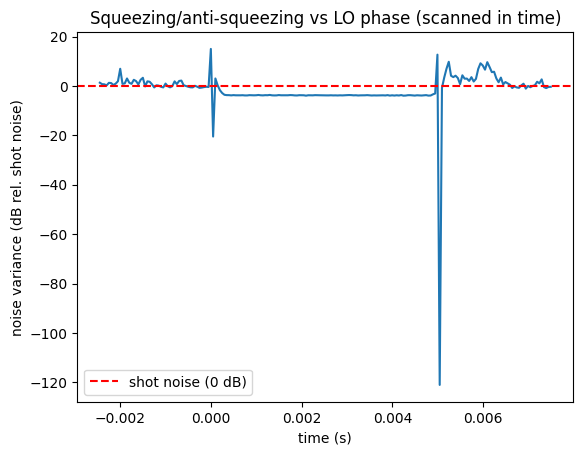

In [ ]:
bin_size = 50000  # ~50 us/bin: enough samples for a low-error variance estimate

n_bins = len(squeezed_light_y) // bin_size
bins = squeezed_light_y[:n_bins * bin_size].reshape(n_bins, bin_size)

# variance relative to shot noise (=1 at shot noise), in dB: <0 dB = squeezing
v_rel = bins.var(axis=1) / normalization_factor # should it be square root or not
v_dB = 10 * np.log10(v_rel)
t = squeezed_light_x[:n_bins * bin_size].reshape(n_bins, bin_size).mean(axis=1)

plt.figure()
plt.plot(t, v_dB)
plt.axhline(0, color='r', ls='--', label='shot noise (0 dB)')
plt.xlabel('time (s)'); plt.ylabel('noise variance (dB rel. shot noise)')
plt.title('Squeezing/anti-squeezing vs LO phase (scanned in time)')
plt.legend()

In [ ]:
i = np.argmin(np.abs(t - 0.002))
print(f"t={t[i]:.6f}s  squeezing={v_dB[i]:.3f} dB")

t=0.001995s  squeezing=-3.752 dB


# Local oscilator tomography and squeezing analysis

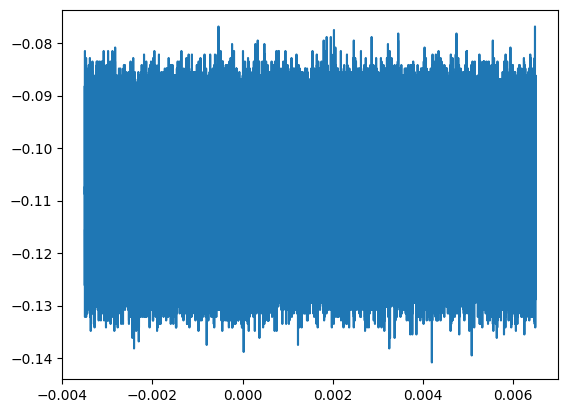

In [7]:
vacuum_data = ScopeData(path='data/ShotNoise.trc',parseAll=False)
vacuum_data_x = vacuum_data.x[:-2]
vacuum_data_y = vacuum_data.y[:-2]

plt.figure()
plt.plot(vacuum_data_x,vacuum_data_y)

In [8]:
vacuum_variance = np.var(vacuum_data_y)
normalization_factor = vacuum_variance / 0.5
print(f"var = {vacuum_variance:.4e}, normalization factor = {normalization_factor:.4e}")

var = 3.5293e-05, normalization factor = 7.0586e-05


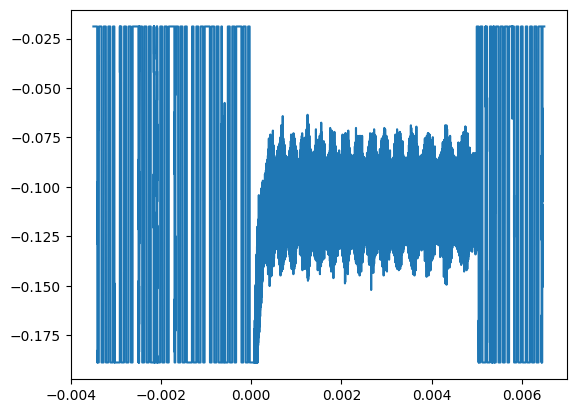

In [9]:
squeezed_light_data = ScopeData(path='data/SweepLO1.trc',parseAll=False)
squeezed_light_x = squeezed_light_data.x[:-2]
squeezed_light_y = squeezed_light_data.y[:-2]

plt.figure()
plt.plot(squeezed_light_x, squeezed_light_y)

squeezing (min)      = -3.749 dB at t=0.004125s
anti-squeezing (max) = 0.771 dB at t=0.004325s


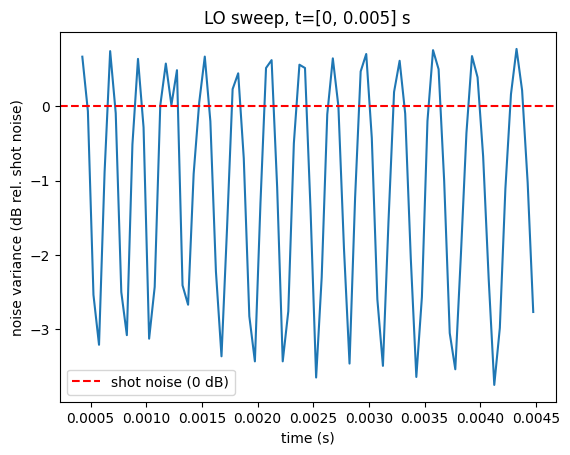

In [10]:
# squeezing from the LO-sweep, restricted to t in [0.000, 0.005] s
mask = (squeezed_light_x >= 0.0004) & (squeezed_light_x <= 0.0045) # since this is where the sweeping happened
xw = squeezed_light_x[mask]
yw = squeezed_light_y[mask]

bin_size = 50000  # ~50 us/bin
n_bins = len(yw) // bin_size
bins = yw[:n_bins * bin_size].reshape(n_bins, bin_size)

v_rel = bins.var(axis=1) / normalization_factor  # variance rel. shot noise
v_dB = 10 * np.log10(v_rel)
t = xw[:n_bins * bin_size].reshape(n_bins, bin_size).mean(axis=1)

plt.figure()
plt.plot(t, v_dB)
plt.axhline(0, color='r', ls='--', label='shot noise (0 dB)')
plt.xlabel('time (s)'); plt.ylabel('noise variance (dB rel. shot noise)')
plt.title('LO sweep, t=[0, 0.005] s')
plt.legend()

print(f"squeezing (min)      = {v_dB.min():.3f} dB at t={t[v_dB.argmin()]:.6f}s")
print(f"anti-squeezing (max) = {v_dB.max():.3f} dB at t={t[v_dB.argmax()]:.6f}s")